#### Goal: Dataset exploration + bias/template evidence (no models)

This notebook writes to out/visualizations/ (plots + csvs)

In [2]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## Paths

In [3]:
OUT_ROOT = "./out"
META_CSV = os.path.join(OUT_ROOT, "metadata", "metadata_enriched.csv")
IMAGES_DIR = os.path.join(OUT_ROOT, "images")
VIZ_DIR = os.path.join(OUT_ROOT, "visualizations")
os.makedirs(VIZ_DIR, exist_ok=True)

assert os.path.exists(META_CSV), f"Missing: {META_CSV} (run 01_build_metadata... first)"

df = pd.read_csv(META_CSV)
print("Loaded:", META_CSV, "shape:", df.shape)
display(df.head(3))

Loaded: ./out/metadata/metadata_enriched.csv shape: (58849, 7)


,source,question,answer,img_id,question_norm,question_type,answer_type
0,Ulcerative Colitis,Are there any abnormalities in the image? Chec...,ulcerative colitis,cla820gl0s3nv071u4fgd7xgq,are there any abnormalities in the image check...,Yes/No,Token
1,Ulcerative Colitis,Are there any anatomical landmarks in the imag...,none,cla820gl0s3nv071u4fgd7xgq,are there any anatomical landmarks in the imag...,Yes/No,None/NA
2,Ulcerative Colitis,Are there any instruments in the image? Check ...,none,cla820gl0s3nv071u4fgd7xgq,are there any instruments in the image check a...,Yes/No,None/NA


## Helpers 
(these functions fallbacks if columns missing)

In [4]:
def norm_text(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def infer_question_type(q: str) -> str:
    qn = norm_text(q)
    if qn.startswith(("is ", "are ", "was ", "were ", "do ", "does ", "can ", "could ", "has ", "have ")):
        return "Yes/No"
    if qn.startswith(("how many", "number of")):
        return "Counting"
    if qn.startswith(("where", "in which", "at what")):
        return "Location"
    if "color" in qn or "colour" in qn:
        return "Color"
    if qn.startswith(("what", "which")):
        return "Entity"
    return "Other"

def infer_answer_type(a: str) -> str:
    an = norm_text(a)
    if an in {"yes", "no"}:
        return "Yes/No"
    if an in {"none", "na", "n a", "n/a", ""}:
        return "None/NA"
    if re.fullmatch(r"\d+", an):
        return "Numeric"
    if ";" in str(a) or "," in str(a):
        return "List"
    return "Token"

if "question_norm" not in df.columns:
    df["question_norm"] = df["question"].astype(str).apply(norm_text)
if "question_type" not in df.columns:
    df["question_type"] = df["question"].astype(str).apply(infer_question_type)
if "answer_type" not in df.columns:
    df["answer_type"] = df["answer"].astype(str).apply(infer_answer_type)


## Basic Stats

Total QA pairs: 58,849
Unique images: 6,500

QA per image (describe):


count    6500.000000
mean        9.053692
std         7.017818
min         1.000000
25%         1.000000
50%         9.000000
75%        17.000000
max        18.000000
dtype: float64

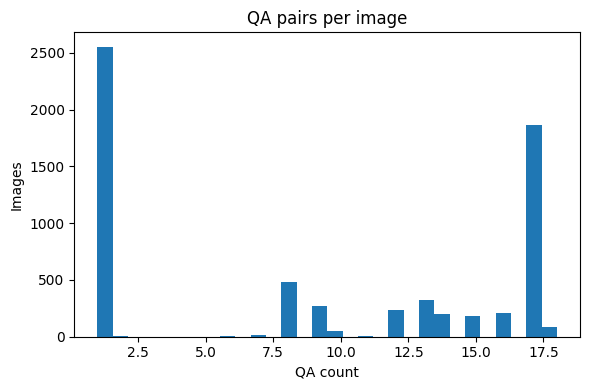

In [5]:
n_qa = len(df)
n_imgs = df["img_id"].nunique()
qa_per_img = df.groupby("img_id").size()

print(f"Total QA pairs: {n_qa:,}")
print(f"Unique images: {n_imgs:,}")
print("\nQA per image (describe):")
display(qa_per_img.describe())

plt.figure(figsize=(6,4))
plt.hist(qa_per_img.values, bins=30)
plt.title("QA pairs per image")
plt.xlabel("QA count")
plt.ylabel("Images")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "qa_per_image_hist.png"), dpi=200)
plt.show()

## SOURCE DISTRIBUTIONS

QA pairs by source:


source
Ulcerative Colitis    16890
Esophagitis           16723
Polyps                13539
Instrument             9197
Normal                 2500
Name: count, dtype: int64

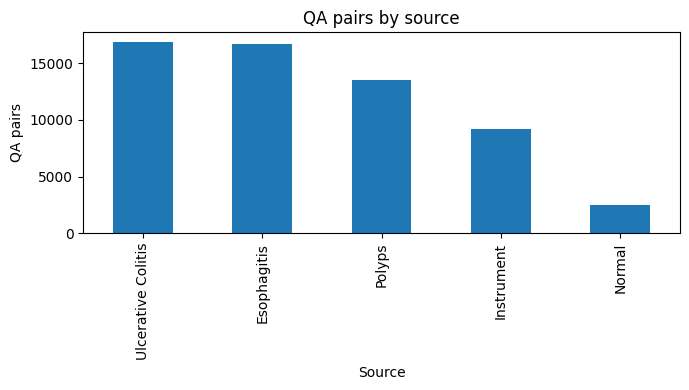

Unique images by source:


source
Normal                2500
Esophagitis           1000
Instrument            1000
Polyps                1000
Ulcerative Colitis    1000
Name: img_id, dtype: int64

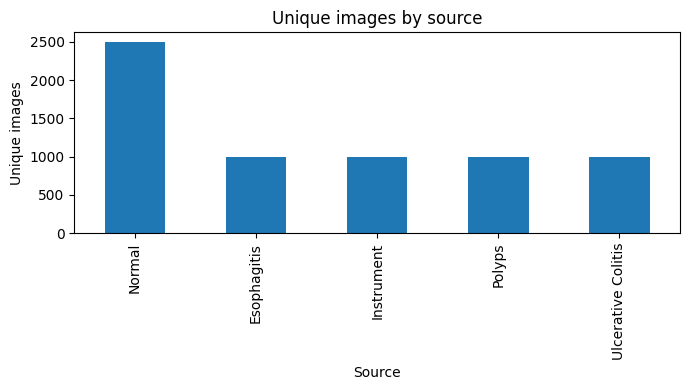

In [6]:
by_source_qa = df["source"].value_counts()
by_source_imgs = df.groupby("source")["img_id"].nunique().sort_values(ascending=False)

by_source_qa.to_csv(os.path.join(VIZ_DIR, "qa_by_source.csv"), header=["qa_pairs"])
by_source_imgs.to_csv(os.path.join(VIZ_DIR, "unique_images_by_source.csv"), header=["unique_images"])

print("QA pairs by source:")
display(by_source_qa)

plt.figure(figsize=(7,4))
by_source_qa.plot(kind="bar")
plt.title("QA pairs by source")
plt.xlabel("Source")
plt.ylabel("QA pairs")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "qa_by_source.png"), dpi=200)
plt.show()

print("Unique images by source:")
display(by_source_imgs)

plt.figure(figsize=(7,4))
by_source_imgs.plot(kind="bar")
plt.title("Unique images by source")
plt.xlabel("Source")
plt.ylabel("Unique images")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "unique_images_by_source.png"), dpi=200)
plt.show()

## QUESTION TYPE DISTRIBUTION

question_type
Yes/No      26515
Entity      10528
Counting    10118
Location     8424
Color        3213
Other          51
Name: count, dtype: int64

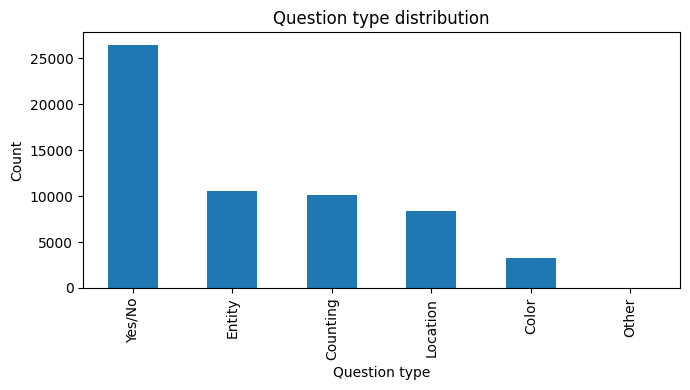

In [7]:
qtype_counts = df["question_type"].value_counts()
qtype_counts.to_csv(os.path.join(VIZ_DIR, "question_type_counts.csv"), header=["count"])

display(qtype_counts)

plt.figure(figsize=(7,4))
qtype_counts.plot(kind="bar")
plt.title("Question type distribution")
plt.xlabel("Question type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "question_type_distribution.png"), dpi=200)
plt.show()

## TOP QUESTION TEMPLATES (BIAS SIGNAL)

In [8]:
top_templates = df["question_norm"].value_counts().head(25)
top_templates.to_csv(os.path.join(VIZ_DIR, "top_question_templates.csv"), header=["count"])
print("Top 25 question templates:")
display(top_templates)


Top 25 question templates:


question_norm
have all polyps been removed                                                  3945
is this finding easy to detect                                                3941
is there text                                                                 3941
is there a green black box artefact                                           3940
what type of procedure is the image taken from                                3939
how many instrumnets are in the image                                         3555
how many findings are present                                                 3429
what type of polyp is present                                                 3331
what is the size of the polyp                                                 3258
where in the image is the instrument                                          3154
are there any instruments in the image check all that are present             3148
how many polyps are in the image                                         

## ANSWER TYPE + TOP SPECIFIC ANSWERS

answer_type
Yes/No     15243
Token      15137
None/NA    10520
Numeric    10156
List        7793
Name: count, dtype: int64

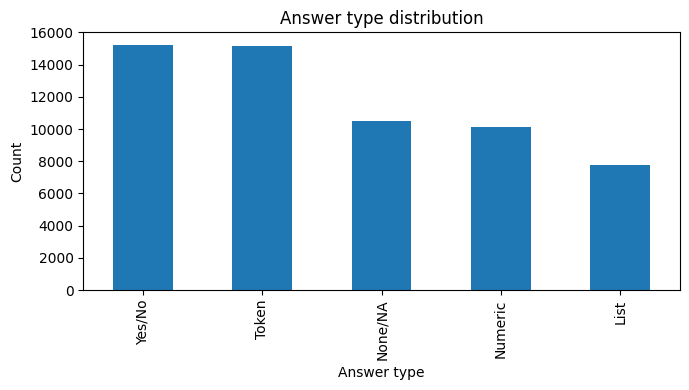

Top 20 specific answers (non-trivial):


answer
0                                                                                                                  4538
1                                                                                                                  4380
colonoscopy                                                                                                        2944
center; center-left; center-right; lower-center; lower-left; lower-right; upper-center; upper-left; upper-right    1794
pink; red; white                                                                                                   1271
polyp                                                                                                              1137
2                                                                                                                  1116
gastroscopy                                                                                                         993
ulcerative colitis               

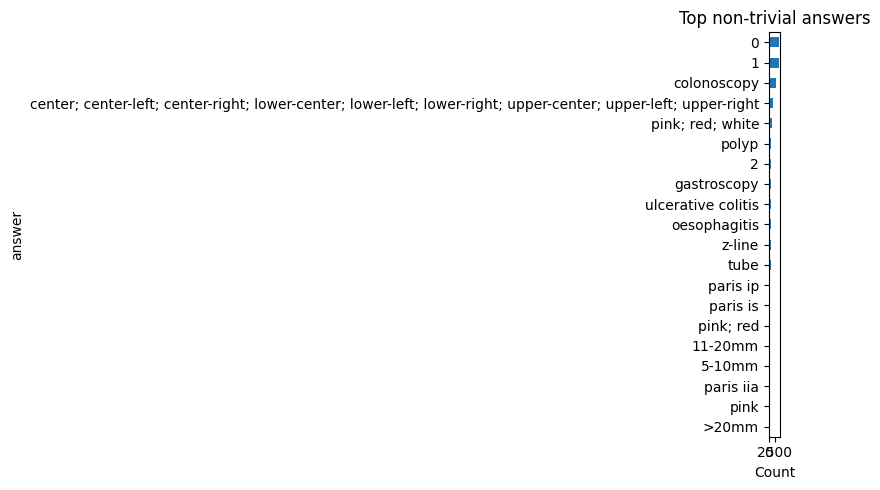

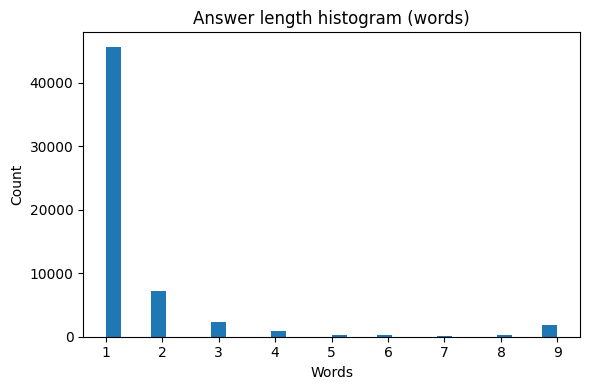

In [9]:
atype_counts = df["answer_type"].value_counts()
atype_counts.to_csv(os.path.join(VIZ_DIR, "answer_type_counts.csv"), header=["count"])
display(atype_counts)

plt.figure(figsize=(7,4))
atype_counts.plot(kind="bar")
plt.title("Answer type distribution")
plt.xlabel("Answer type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "answer_type_distribution.png"), dpi=200)
plt.show()

ans = df["answer"].astype(str).str.strip()
ans_l = ans.str.lower()

# “non-trivial” = remove frequent non-informative answers
drop_set = {"yes", "no", "none", "na", "n/a", "not relevant", ""}
mask = ~ans_l.isin(drop_set)

top_nontrivial = ans[mask].value_counts().head(20)
top_nontrivial.to_csv(os.path.join(VIZ_DIR, "top_nontrivial_answers.csv"), header=["count"])
print("Top 20 specific answers (non-trivial):")
display(top_nontrivial)

plt.figure(figsize=(8,5))
top_nontrivial.sort_values().plot(kind="barh")
plt.title("Top non-trivial answers")
plt.xlabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "top_nontrivial_answers.png"), dpi=200)
plt.show()

ans_len = ans.str.split().str.len()
plt.figure(figsize=(6,4))
plt.hist(ans_len.values, bins=30)
plt.title("Answer length histogram (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "answer_len_hist.png"), dpi=200)
plt.show()


## SOURCE × QUESTION TYPE CROSSTAB

question_type,Color,Counting,Entity,Location,Other,Yes/No
source,,,,,,
Esophagitis,1077,2967,2967,2964,11,6737
Instrument,164,1595,1265,1129,26,5018
Normal,0,0,0,0,0,2500
Polyps,978,2576,3316,1354,8,5307
Ulcerative Colitis,994,2980,2980,2977,6,6953


<Figure size 900x500 with 0 Axes>

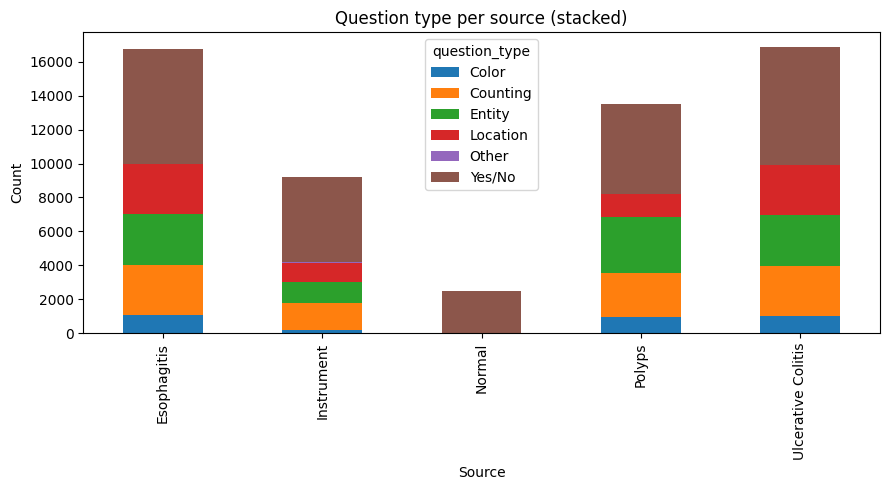

In [10]:
ct = pd.crosstab(df["source"], df["question_type"]).sort_index()
ct.to_csv(os.path.join(VIZ_DIR, "crosstab_source_qtype.csv"))
display(ct)

plt.figure(figsize=(9,5))
ct.plot(kind="bar", stacked=True, figsize=(9,5))
plt.title("Question type per source (stacked)")
plt.xlabel("Source")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "qtype_per_source_stacked.png"), dpi=200)
plt.show()
